In [2]:
import ee 
from RadGEEToolbox import GenericCollection, LandsatCollection, get_palette
# import GEE_UBM
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run, check_merged_collection
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [3]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

# try:
#     ee.Initialize()
# except Exception as e:
#     ee.Authenticate()
#     ee.Initialize()

In [4]:
UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary").geometry()

#### Update `zonal_stats_df = pd.read_csv()` with the path of the data you are looking to plot

In [5]:
# zonal_stats_df = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\GSL_Basin\\Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_POLKsatM_DAYMETSNOM_ETEEMETRIC_IRRIm_M_m3_Zonal_Stats_GSL_Basin_Watershed.csv')
# zonal_stats_df = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\All_Watersheds\\GSL_Basin_Watershed\\Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_POLKsatM_DAYMETSNOM_ETEEMETRIC_IRRIm_M_m3_Zonal_Stats_GSL_Basin.csv')
zonal_stats_df = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\All_Watersheds\\GSL_Basin_Watershed\\Mod_UBM_1_RF1kmST_POLPor_OLMFC_HHSWP_POLKsatM_PRISMSNOM_ETEEMETRIC_IRRIm_M_m3_Zonal_Stats_GSL_Basin.csv')
zonal_stats_df['Date'] = pd.to_datetime(zonal_stats_df['Date'])
print(zonal_stats_df.head())

        Date   Recharge_m3     Runoff_m3  Soil_Water_End_m3        AET_m3  \
0 2005-01-01  2.161298e+09  5.568638e+07       7.004697e+09  1.410589e+08   
1 2005-02-01  1.410790e+09  1.112566e+07       7.135410e+09  2.322234e+08   
2 2005-03-01  1.204424e+09  5.785884e+07       7.041302e+09  9.598741e+08   
3 2005-04-01  1.233197e+09  1.895062e+05       7.122428e+09  8.812755e+08   
4 2005-05-01  1.812433e+09  6.390692e+06       7.217750e+09  1.205976e+09   

   Precip_and_Snowmelt_m3  Irrigation_m3  
0            3.123778e+09   0.000000e+00  
1            2.019651e+09   0.000000e+00  
2            2.219004e+09   0.000000e+00  
3            2.345376e+09   4.383050e+07  
4            3.356854e+09   1.139593e+08  


# Matplotlib figures

#### Comment out lines not included in the dataset you are looking to plot (AET and Precip_and_Snowmelt may not be included in the dataset)

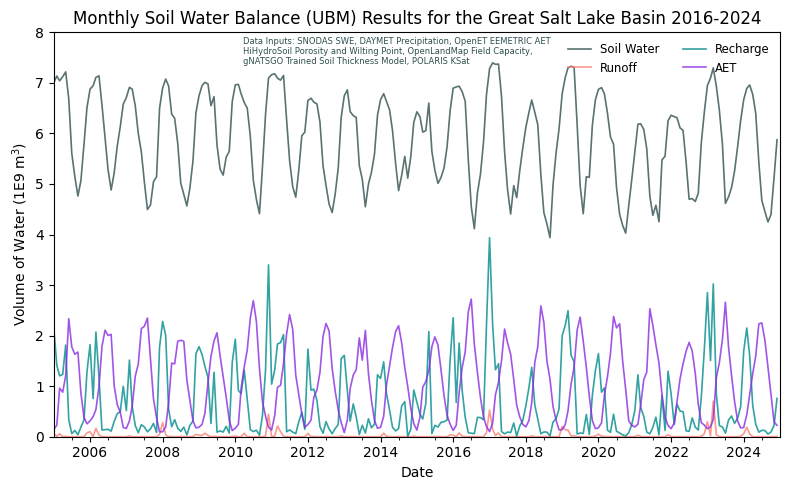

In [6]:
markersize = 0
alpha = 0.8
linewidth = 1.2
plt.figure(figsize=(8,5))
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkslategrey', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Soil Water')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='salmon', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Runoff')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Recharge_m3'], marker='o', color='darkcyan', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Recharge') #darkorchid
plt.plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='blueviolet', markersize=markersize, linewidth=linewidth, alpha=alpha, label='AET')
# plt.plot(zonal_stats_df['Date'], zonal_stats_df['Precip_and_Snowmelt_m3'], marker='o', color='deepskyblue', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Precipitation and Snowmelt')
plt.xlim(pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-31'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(7))
plt.gca().yaxis.get_offset_text().set_visible(False)
plt.ylim(0, 8E9)
plt.title('Monthly Soil Water Balance (UBM) Results for the Great Salt Lake Basin 2016-2024')
plt.xlabel('Date')
plt.ylabel('Volume of Water (1E9 m$^3$)')
plt.legend(loc='upper right', fontsize='small', frameon=False, ncol=2)
plt.annotate('Data Inputs: SNODAS SWE, DAYMET Precipitation, OpenET EEMETRIC AET\nHiHydroSoil Porosity and Wilting Point, OpenLandMap Field Capacity,\ngNATSGO Trained Soil Thickness Model, POLARIS KSat', xy=(0,0), xycoords='figure fraction', xytext=(175,305), textcoords='offset points', ha='left', va='bottom', fontsize=6, color='darkslategray')
plt.tight_layout()
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Aggregated_Modified1_UBM_UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M\\GSL_Basin_UBM_M1_Soil_Water_Balance_2016_2024.png', dpi=600)
plt.show()

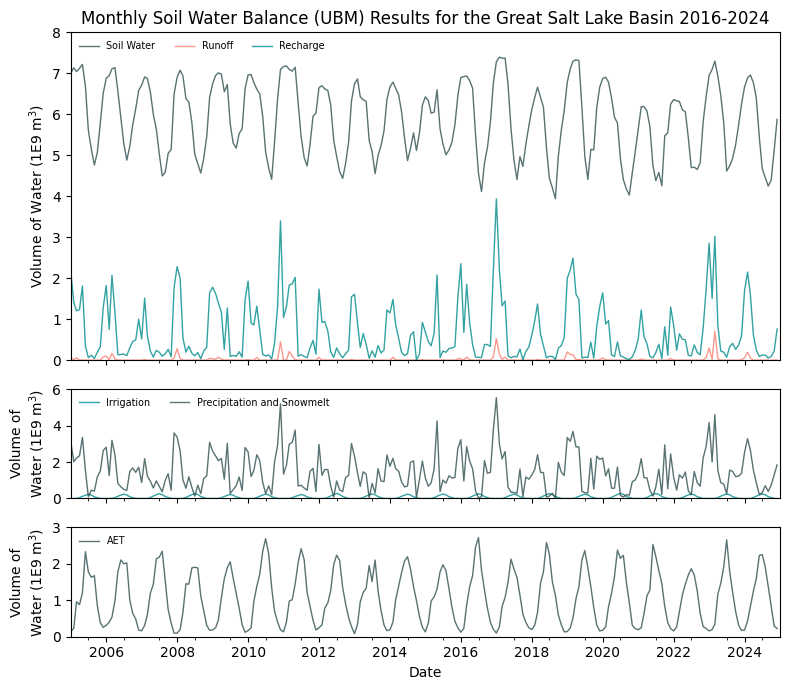

In [7]:
markersize = 0
alpha = 0.8
linewidth = 1 #1.2
# plt.figure(figsize=(8,5))
fig, ax = plt.subplots(figsize=(8,7), nrows=3, ncols=1, sharex=True, height_ratios=[3, 1, 1])
ax[0].plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkslategrey', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Soil Water')
ax[0].plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='salmon', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Runoff')
ax[0].plot(zonal_stats_df['Date'], zonal_stats_df['Recharge_m3'], marker='o', color='darkcyan', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Recharge') #darkorchid
ax[2].plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='darkslategrey', markersize=markersize, linewidth=linewidth, alpha=alpha, label='AET')
ax[1].plot(zonal_stats_df['Date'], zonal_stats_df['Irrigation_m3'], marker='o', color='darkcyan', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Irrigation')
ax[1].plot(zonal_stats_df['Date'], zonal_stats_df['Precip_and_Snowmelt_m3'], marker='o', color='darkslategrey', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Precipitation and Snowmelt')
# plt.plot(zonal_stats_df['Date'], zonal_stats_df['Precip_and_Snowmelt_m3'], marker='o', color='deepskyblue', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Precipitation and Snowmelt')
ax[0].set_xlim(pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-31'))
ax[0].xaxis.set_minor_locator(mdates.MonthLocator(7))
ax[0].yaxis.get_offset_text().set_visible(False)
ax[1].yaxis.get_offset_text().set_visible(False)
ax[2].yaxis.get_offset_text().set_visible(False)
ax[0].set_ylim(0, 8E9)
ax[1].set_ylim(0, 6E9)
ax[2].set_ylim(0, 3E9)
ax[0].set_title('Monthly Soil Water Balance (UBM) Results for the Great Salt Lake Basin 2016-2024')
ax[2].set_xlabel('Date')
ax[0].set_ylabel('Volume of Water (1E9 m$^3$)')
ax[1].set_ylabel('Volume of\nWater (1E9 m$^3$)')
ax[2].set_ylabel('Volume of\nWater (1E9 m$^3$)')
ax[0].legend(loc='upper left', fontsize='x-small', frameon=False, ncol=3)
ax[1].legend(loc='upper left', fontsize='x-small', frameon=False, ncol=3)
ax[2].legend(loc='upper left', fontsize='x-small', frameon=False, ncol=3)
# plt.annotate('Data Inputs: SNODAS SWE, DAYMET Precipitation, OpenET EEMETRIC AET\nHiHydroSoil Porosity and Wilting Point, OpenLandMap Field Capacity,\ngNATSGO Trained Soil Thickness Model, POLARIS KSat', xy=(0,0), xycoords='figure fraction', xytext=(175,305), textcoords='offset points', ha='left', va='bottom', fontsize=6, color='darkslategray')
plt.tight_layout()
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Aggregated_Modified1_UBM_UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M\\GSL_Basin_UBM_M1_Soil_Water_Balance_2016_2024.png', dpi=600)
plt.show()

In [8]:
terra_stats = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\GSL_Basin\\GSL_Basin_Terraclimate_Stats_2005_2024.csv')
terra_stats['Date'] = pd.to_datetime(terra_stats['Date'])
print(terra_stats.head())

        Date  Terraclimate_Runoff_m3  Terraclimate_Soil_Water_m3  \
0 2005-01-01            4.064819e+06                9.531607e+09   
1 2005-02-01            3.345220e+07                1.478606e+10   
2 2005-03-01            4.752787e+08                1.925540e+10   
3 2005-04-01            5.414544e+08                1.645861e+10   
4 2005-05-01            1.809518e+08                1.197719e+10   

   Terraclimate_AET_m3  
0         4.411050e+07  
1         1.001738e+09  
2         1.768788e+10  
3         2.190977e+10  
4         2.629513e+10  


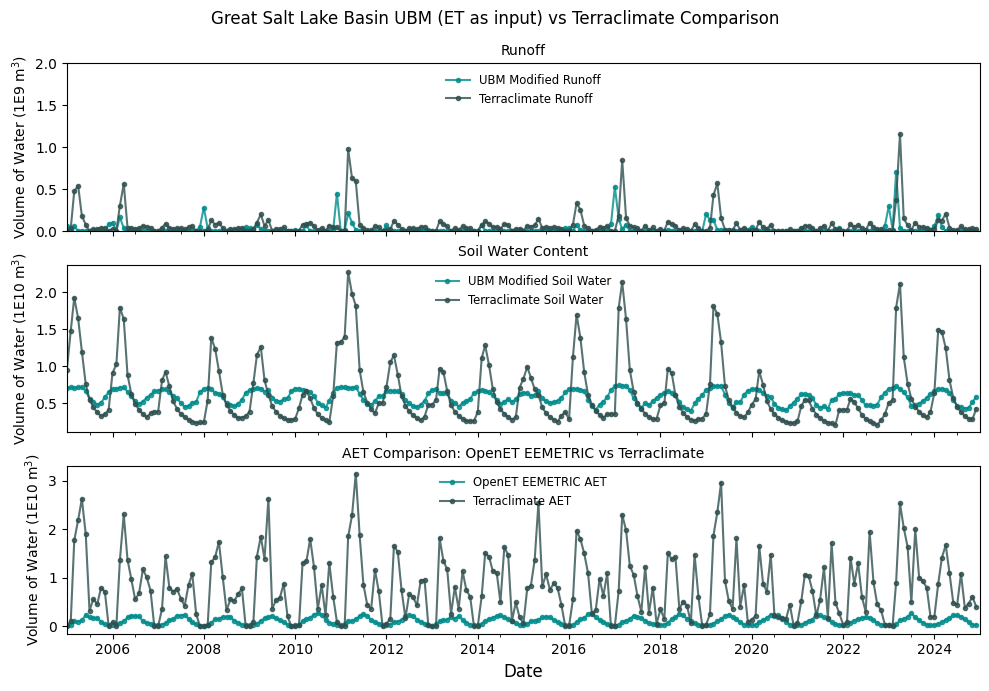

In [9]:
fig, ax = plt.subplots(figsize=(10,7), nrows=3, sharex=True)
markersize = 3
plt.suptitle('Great Salt Lake Basin UBM (ET as input) vs Terraclimate Comparison')
ax[0].plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='UBM Modified Runoff')
ax[0].plot(terra_stats['Date'], terra_stats['Terraclimate_Runoff_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate Runoff')
ax[0].legend(loc='upper center', fontsize='small', frameon=False)
ax[0].set_title('Runoff', fontsize=10)
# ax[0].set_ylim(0, 1.25E9)
ax[0].set_ylim(0, 2E9)
ax[0].set_xlim(pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-31'))
ax[0].xaxis.set_minor_locator(mdates.MonthLocator(7))
ax[0].yaxis.get_offset_text().set_visible(False)
ax[0].set_ylabel('Volume of Water (1E9 m$^3$)')
# ax[0].plot(zonal_stats_df['Runoff_m3'], terra_stats['Terraclimate_Runoff_m3'], marker='o', color='deepskyblue', markersize=markersize, linewidth=0, alpha=alpha)

ax[1].plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='UBM Modified Soil Water')
ax[1].plot(terra_stats['Date'], terra_stats['Terraclimate_Soil_Water_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate Soil Water')
ax[1].set_title('Soil Water Content', fontsize=10)
ax[1].legend(loc='upper center', fontsize='small', frameon=False)
ax[1].yaxis.get_offset_text().set_visible(False)
ax[1].set_ylabel('Volume of Water (1E10 m$^3$)')

ax[2].plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='OpenET EEMETRIC AET')
ax[2].plot(terra_stats['Date'], terra_stats['Terraclimate_AET_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate AET')
ax[2].set_title('AET Comparison: OpenET EEMETRIC vs Terraclimate', fontsize=10)
ax[2].legend(loc='upper center', fontsize='small', frameon=False)
ax[2].yaxis.get_offset_text().set_visible(False)
ax[2].set_ylabel('Volume of Water (1E10 m$^3$)')
ax[2].set_xlabel('Date', fontsize=12)

# reduce the vertical space between subplots


plt.tight_layout()
fig.subplots_adjust(hspace=0.2)
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Aggregated_Modified1_UBM_UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M\\GSL_Basin_UBM_M1_Soil_Water_Balance_2016_2024_Compared_to_Terraclimate.png', dpi=600)

# Plotly figures

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Pre-process: Divide value columns by 1e9 so axes show "1, 2, 3" instead of "1B"
cols_to_plot = ['Soil_Water_End_m3', 'Runoff_m3', 'Recharge_m3', 'Irrigation_m3', 
                'Precip_and_Snowmelt_m3', 'AET_m3']
# Create a copy for plotting so we don't mess up original data
plot_df = zonal_stats_df.copy()
plot_df[cols_to_plot] = plot_df[cols_to_plot] / 1e9

# 2. Configuration: Map rows to specific columns and colors
# Format: (Row Index, Column Name, Label, Color)
plots_config = [
    (1, 'Soil_Water_End_m3', 'Soil Water', 'darkslategray'),
    (1, 'Runoff_m3', 'Runoff', 'salmon'),
    (1, 'Recharge_m3', 'Recharge', 'darkcyan'),
    (2, 'Irrigation_m3', 'Irrigation', 'darkcyan'),
    (2, 'Precip_and_Snowmelt_m3', 'Precipitation', 'darkslategray'),
    (3, 'AET_m3', 'AET', 'darkslategray'),
]

# 3. Setup Figure
fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.03,
    row_heights=[0.6, 0.2, 0.2],
    subplot_titles=("Monthly Soil Water Balance (UBM)", "", "")
)

# 4. Loop to add traces (Much less code!)
for row, col_name, label, color in plots_config:
    fig.add_trace(go.Scatter(
        x=plot_df['Date'], y=plot_df[col_name],
        name=label, mode='lines+markers', # lines+markers matches your style
        marker=dict(size=4), line=dict(width=1.5, color=color)
    ), row=row, col=1)

# 5. The "Publication Quality" Fixes
fig.update_layout(
    height=800, width=900, plot_bgcolor='white',
    legend=dict(orientation="h", y=1, x=0.1)
)

# Global Axis styling (Borders, Ticks, Fonts)
fig.update_xaxes(
    showline=True, linewidth=1, linecolor='black', mirror=True, # The Box border
    showgrid=False, gridcolor='lightgrey',
    ticks="outside",
    minor=dict(
        ticklen=4,  # Length of minor tick
        tickcolor="black",
        dtick="M6", # Every 1 Month (since major is likely Year)
        showgrid=False # Optional: grid lines for minor ticks
    )
)
fig.update_yaxes(
    showline=True, linewidth=1, linecolor='black', mirror=True, # The Box border
    showgrid=False, gridcolor='lightgrey', ticks='outside',
    title_text="Volume (1E9 m³)"
)

# Specific Limits
fig.update_yaxes(range=[0, 8], row=1, col=1)
fig.update_yaxes(range=[0, 6], row=2, col=1)
fig.update_yaxes(range=[0, 3], row=3, col=1)
fig.update_xaxes(range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-31')], title_text="Date", row=3, col=1, dtick="M24")

fig.show()

In [71]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# (Assuming zonal_stats_df is loaded and prepared)
cols_to_plot = ['Soil_Water_End_m3', 'Runoff_m3', 'Recharge_m3', 'Irrigation_m3', 
                'Precip_and_Snowmelt_m3', 'AET_m3']
plot_df = zonal_stats_df.copy()
plot_df[cols_to_plot] = plot_df[cols_to_plot] * 0.000810714 #/ 1e9

# 1. Config: Map Rows to Data
# Format: (Row, Col_Name, Label, Color)
plots_config = [
    (1, 'Soil_Water_End_m3', 'Soil Water', 'darkslategray'),
    (1, 'Runoff_m3', 'Runoff', 'salmon'),
    (1, 'Recharge_m3', 'Recharge', 'darkcyan'),
    (2, 'Irrigation_m3', 'Irrigation', 'darkcyan'),
    (2, 'Precip_and_Snowmelt_m3', 'Precipitation', 'darkslategray'),
    (3, 'AET_m3', 'AET', 'darkslategray'),
]

# 2. Setup Figure
fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    row_heights=[0.5, 0.25, 0.25],
    subplot_titles=("Soil Water Balance", "Irrigation & Precip", "AET")
)

# 3. The Loop (Solving the separate legend issue)
for row, col_name, label, color in plots_config:
    # Logic: Row 1 uses 'legend', Row 2 uses 'legend2', etc.
    legend_ref = 'legend' if row == 1 else f'legend{row}'
    
    fig.add_trace(go.Scatter(
        x=plot_df['Date'], y=plot_df[col_name],
        name=label,
        legend=legend_ref,  # Dynamic assignment
        mode='lines+markers',
        marker=dict(size=3),
        line=dict(color=color, width=1.5)
    ), row=row, col=1)

# 4. Global Font Settings (The "Font Hammer")
# This sets the font for EVERYTHING (Ticks, Legend, Hover text)
target_font = "Times New Roman"  # changing to Serif to make it obvious
target_size = 14

fig.update_layout(
    height=800, width=1000, plot_bgcolor='white',
    font=dict(family=target_font, size=target_size, color="black"),
    
    # Position the 3 legends
    legend=dict(x=1.02, y=0.98, xanchor="left", yanchor="top"),
    legend2=dict(x=1.02, y=0.45, xanchor="left", yanchor="top"),
    legend3=dict(x=1.02, y=0.15, xanchor="left", yanchor="top"),
    margin=dict(t=40, b=40, l=40, r=40)
)

# 5. Fix Subplot Titles (The part that usually gets stuck)
fig.update_annotations(font=dict(family=target_font, size=16))

# 6. Axis Styling
fig.update_xaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False, gridcolor='lightgrey',
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font), ticks="outside",
    range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-31')], ticklen=6,
    minor=dict(
        ticklen=4,
        dtick="M6",
        showgrid=False)
)
fig.update_yaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False, gridcolor='lightgrey',
    title_text="Volume (1E6 acre-ft)",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    minor=dict(ticklen=4, dtick=0.5E6)
)

fig.update_yaxes(range=[0, 6E6], row=1, col=1)
fig.update_yaxes(range=[0, 5E6], row=2, col=1)
fig.update_yaxes(range=[0, 2.5E6], row=3, col=1)

fig.update_xaxes(title_text="Date", row=3, col=1)

fig.show()

In [58]:
import plotly.graph_objects as go
import pandas as pd

# 1. Pre-process: Calculate net water balance
plot_df = zonal_stats_df.copy()
plot_df['Net_Water_Balance_m3'] = (
    plot_df['Irrigation_m3'] + 
    plot_df['Precip_and_Snowmelt_m3'] - 
    plot_df['AET_m3']
) * 0.000810714 # Convert to acre-ft

# Better approach: Single continuous line with dual-color fill
fig = go.Figure()

# Add the main line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Net_Water_Balance_m3'],
    mode='lines',
    line=dict(color='darkslategray', width=1),
    name='Water Balance'
))

# Add positive fill (blue)
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Net_Water_Balance_m3'].clip(lower=0),  # Only positive values
    fill='tozeroy',
    fillcolor='rgba(0, 120, 215, 0.3)',
    line=dict(width=0),
    name='Surplus',
    hoverinfo='skip'
))

# Add negative fill (red)
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Net_Water_Balance_m3'].clip(upper=0),  # Only negative values
    fill='tozeroy',
    fillcolor='rgba(220, 20, 60, 0.3)',
    line=dict(width=0),
    name='Deficit',
    hoverinfo='skip'
))

# ... rest of styling code ...

# 5. Add zero line for reference
fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.5)

# 6. Global styling (matching your last plot)
target_font = "Times New Roman"
target_size = 14

fig.update_layout(
    height=600, width=1000, plot_bgcolor='white',
    font=dict(family=target_font, size=target_size, color="black"),
    title_text="Climatic Water Balance (Irrigation + Precipitation - AET)",
    title_x=0.5,
    title_y=0.98,
    title_font=dict(family=target_font, size=18),
    margin=dict(t=30, b=60, l=60, r=60),
    legend=dict(x=0.02, y=0.99, xanchor="left", yanchor="top")
)

# 7. Axis styling
fig.update_xaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Date",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    ticklen=6,
    range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-01')],
    dtick="M12",
    minor=dict(ticklen=4, dtick="M6", showgrid=False)
)

fig.update_yaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Net Water Balance (acre-ft)",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    ticklen=6
)

fig.show()

In [68]:
import plotly.graph_objects as go
import pandas as pd

# Prepare data (ensure sorted and handle missing)
plot_df = zonal_stats_df.copy().sort_values('Date')
plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']] = plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']].fillna(0)

# Net monthly balance (inputs - outputs), convert to acre-ft
plot_df['Net_Water_Balance_acft'] = (
    plot_df['Irrigation_m3'] +
    plot_df['Precip_and_Snowmelt_m3'] -
    plot_df['AET_m3']
) * 0.000810714

# Cumulative water balance (acre-ft)
plot_df['Cum_Water_Balance_acft'] = plot_df['Net_Water_Balance_acft'].cumsum()

# Linear fit to plot_df['Cum_Recharge_acft']
fit = np.polyfit(plot_df.index, plot_df['Cum_Water_Balance_acft'], 1)
fit_fn = np.poly1d(fit)
# R2 calculation
y_true = plot_df['Cum_Water_Balance_acft'].values
y_pred = fit_fn(plot_df.index)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"R² of cumulative water balance linear fit: {r_squared:.4f}")

fig = go.Figure()

# Main cumulative line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Water_Balance_acft'],
    mode='lines',
    line=dict(color='darkslategray', width=1.5),
    name='Cumulative Water Balance'
))

# Positive fill (blue) above zero
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Water_Balance_acft'].clip(lower=0),
    fill='tozeroy',
    fillcolor='rgba(0, 255, 183, 0.15)',
    line=dict(width=0),
    name='Surplus',
    hoverinfo='skip'
))

# # Negative fill (red) below zero
# fig.add_trace(go.Scatter(
#     x=plot_df['Date'],
#     y=plot_df['Cum_Water_Balance_acft'].clip(upper=0),
#     fill='tozeroy',
#     fillcolor='rgba(220, 20, 60, 0.3)',
#     line=dict(width=0),
#     name='Deficit',
#     hoverinfo='skip'
# ))

# add linear fit line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=fit_fn(plot_df.index),
    mode='lines',
    line=dict(color='darkslategrey', width=2, dash='dash'),
    name=f'Linear Fit - R²={r_squared:.4f} - Slope={fit[0]:.0f} ac-ft/month'
)) 

# Zero line
# fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.8)

# Styling (matching your last plot)
target_font = "Times New Roman"
target_size = 14

fig.update_layout(
    height=600, width=800, plot_bgcolor='white',
    font=dict(family=target_font, size=target_size, color="black"),
    title_text="Cumulative Climatic Water Balance (Irrigation + Precipitation - AET)",
    title_x=0.5,
    title_y=0.98,
    title_font=dict(family=target_font, size=18),
    margin=dict(t=30, b=60, l=60, r=60),
    legend=dict(x=0.02, y=0.99, xanchor="left", yanchor="top")
)

fig.update_xaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Date",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font, size=12),
    ticks="outside",
    ticklen=6,
    range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-01')],
    dtick="M12",
    minor=dict(ticklen=4, dtick="M6", showgrid=False)
)

fig.update_yaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Cumulative Water Balance (acre-ft)",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    ticklen=6,
    range=[0, 95E6]
)

fig.show()

R² of cumulative water balance linear fit: 0.9840


In [65]:
import plotly.graph_objects as go
import pandas as pd

# Prepare data (ensure sorted and handle missing)
plot_df = zonal_stats_df.copy().sort_values('Date')
# plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']] = plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']].fillna(0)

# Net monthly balance (inputs - outputs), convert to acre-ft
plot_df['Inputs_acft'] = (
    plot_df['Precip_and_Snowmelt_m3'] + plot_df['Irrigation_m3']
) * 0.000810714

# Cumulative water balance (acre-ft)
plot_df['Cum_Inputs_acft'] = plot_df['Inputs_acft'].cumsum()

# Linear fit to plot_df['Cum_Recharge_acft']
fit = np.polyfit(plot_df.index, plot_df['Cum_Inputs_acft'], 1)
fit_fn = np.poly1d(fit)
# R2 calculation
y_true = plot_df['Cum_Inputs_acft'].values
y_pred = fit_fn(plot_df.index)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"R² of cumulative inputs linear fit: {r_squared:.4f}")

fig = go.Figure()

# Main cumulative line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Inputs_acft'],
    mode='lines',
    line=dict(color='darkslategray', width=1.5),
    name='Cumulative Water Balance'
))

# Positive fill (blue) above zero
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Inputs_acft'].clip(lower=0),
    fill='tozeroy',
    fillcolor='rgba(0, 255, 183, 0.15)',
    line=dict(width=0),
    name='Surplus',
    hoverinfo='skip'
))

# Negative fill (red) below zero
# fig.add_trace(go.Scatter(
#     x=plot_df['Date'],
#     y=plot_df['Cum_Inputs_acft'].clip(upper=0),
#     fill='tozeroy',
#     fillcolor='rgba(220, 20, 60, 0.3)',
#     line=dict(width=0),
#     name='Deficit',
#     hoverinfo='skip'
# ))

# add linear fit line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=fit_fn(plot_df.index),
    mode='lines',
    line=dict(color='darkslategrey', width=2, dash='dash'),
    name=f'Linear Fit - R²={r_squared:.4f} - Slope={fit[0]:.0f} ac-ft/month'
)) 

# Zero line
# fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.8)

# Styling (matching your last plot)
target_font = "Times New Roman"
target_size = 14

fig.update_layout(
    height=600, width=800, plot_bgcolor='white',
    font=dict(family=target_font, size=target_size, color="black"),
    title_text="Cumulative Inputs (precipitation + snowmelt + irrigation; acre-ft)",
    title_x=0.5,
    title_y=0.98,
    title_font=dict(family=target_font, size=18),
    margin=dict(t=30, b=60, l=60, r=60),
    legend=dict(x=0.02, y=0.99, xanchor="left", yanchor="top")
)

fig.update_xaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Date",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font, size=12),
    ticks="outside",
    ticklen=6,
    range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-01')],
    dtick="M12",
    minor=dict(ticklen=4, dtick="M6", showgrid=False)
)

fig.update_yaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Cumulative Inputs (acre-ft)",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    ticklen=6,
    range=[0, 300E6]
)

fig.show()

R² of cumulative inputs linear fit: 0.9990


In [67]:
import plotly.graph_objects as go
import pandas as pd

# Prepare data (ensure sorted and handle missing)
plot_df = zonal_stats_df.copy().sort_values('Date')
# plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']] = plot_df[['Irrigation_m3','Precip_and_Snowmelt_m3','AET_m3']].fillna(0)

# Net monthly balance (inputs - outputs), convert to acre-ft
plot_df['Recharge_acft'] = (
    plot_df['Recharge_m3']
) * 0.000810714

# Cumulative water balance (acre-ft)
plot_df['Cum_Recharge_acft'] = plot_df['Recharge_acft'].cumsum()

# Linear fit to plot_df['Cum_Recharge_acft']
fit = np.polyfit(plot_df.index, plot_df['Cum_Recharge_acft'], 1)
fit_fn = np.poly1d(fit)
# R2 calculation
y_true = plot_df['Cum_Recharge_acft'].values
y_pred = fit_fn(plot_df.index)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"R² of cumulative recharge linear fit: {r_squared:.4f}")

fig = go.Figure()

# Main cumulative line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Recharge_acft'],
    mode='lines',
    line=dict(color='darkslategray', width=1.5),
    name='Cumulative Water Balance'
))

# Positive fill (blue) above zero
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=plot_df['Cum_Recharge_acft'].clip(lower=0),
    fill='tozeroy',
    fillcolor='rgba(0, 255, 183, 0.15)',
    line=dict(width=0),
    name='Surplus',
    hoverinfo='skip'
))

# # Negative fill (red) below zero
# fig.add_trace(go.Scatter(
#     x=plot_df['Date'],
#     y=plot_df['Cum_Recharge_acft'].clip(upper=0),
#     fill='tozeroy',
#     fillcolor='rgba(220, 20, 60, 0.3)',
#     line=dict(width=0),
#     name='Deficit',
#     hoverinfo='skip'
# ))

# add linear fit line
fig.add_trace(go.Scatter(
    x=plot_df['Date'],
    y=fit_fn(plot_df.index),
    mode='lines',
    line=dict(color='darkslategrey', width=2, dash='dash'),
    name=f'Linear Fit - R²={r_squared:.4f} - Slope={fit[0]:.0f} ac-ft/month'
)) 

# Zero line
# fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.8)

# Styling (matching your last plot)
target_font = "Times New Roman"
target_size = 14

fig.update_layout(
    height=600, width=800, plot_bgcolor='white',
    font=dict(family=target_font, size=target_size, color="black"),
    title_text="Cumulative Recharge (acre-ft)",
    title_x=0.5,
    title_y=0.98,
    title_font=dict(family=target_font, size=18),
    margin=dict(t=30, b=60, l=60, r=60),
    legend=dict(x=0.02, y=0.99, xanchor="left", yanchor="top")
)

fig.update_xaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Date",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font, size=12),
    ticks="outside",
    ticklen=6,
    range=[pd.Timestamp('2005-01-01'), pd.Timestamp('2024-12-01')],
    dtick="M12",
    minor=dict(ticklen=4, dtick="M6", showgrid=False)
)

fig.update_yaxes(
    showline=True, linewidth=1.2, linecolor='black', mirror=True,
    showgrid=False,
    title_text="Cumulative Recharge (acre-ft)",
    title_font=dict(family=target_font),
    tickfont=dict(family=target_font),
    ticks="outside",
    ticklen=6,
    range=[0, 140E6]
)

fig.show()

R² of cumulative recharge linear fit: 0.9974
